<a href="https://colab.research.google.com/github/JulioDuarte24/FC_CAIXAVERSO_ML1/blob/main/Projeto_ML_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Projeto ML II
## Avaliação de Modelos de Classificação em Machine Learning com Python


### Introdução

Construir um modelo é apenas metade da batalha. A outra, igualmente crucial, é **avaliar o quão bem** esse modelo realmente funciona. Um modelo que parece bom no papel pode falhar no mundo real se não for avaliado corretamente.

Para modelos de **classificação**, que predizem uma categoria ou classe (por exemplo, sim/não, gato/cachorro, fraude/não fraude), temos um conjunto específico de métricas que nos ajudam a entender seu desempenho de diferentes ângulos. Vamos explorar isso passo a passo, usando Python!

### Passo 1: Importar Bibliotecas Essenciais

Começaremos importando as bibliotecas Python que nos fornecerão as ferramentas necessárias para manipular dados, construir modelos e, o mais importante, avaliá-los. As principais são `pandas` para manipulação de dados, `scikit-learn` para modelagem e métricas, e `matplotlib`/`seaborn` para visualização.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Configurações para melhor visualização dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


### Passo 2: Importar e Ler a Base de Dados

Para demonstrar, vamos usar um conjunto de dados de exemplo popular do scikit-learn. Usaremos o dataset Iris para um exemplo simples de classificação. (No entanto, em um cenário real, você provavelmente leria um arquivo CSV ou outro formato).

In [31]:
from sklearn.datasets import load_iris

# Carregar o dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Podemos converter para um DataFrame para melhor visualização e manipulação
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = iris.target_names[y]

print("Essas são as primeiras 5 linhas do DataFrame:")
display(df.head())

print("\nDistribuição das classes (Target):")
display(df['species'].value_counts())


Essas são as primeiras 5 linhas do DataFrame:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Distribuição das classes (Target):


,count
species,
setosa,50
versicolor,50
virginica,50


### Passo 3: Pré-processamento dos Dados

O pré-processamento é vital para preparar os dados para o modelo. Isso pode incluir:

*   **Tratamento de valores ausentes:** Preenchimento (imputação) ou remoção.
*   **Codificação de variáveis categóricas:** Transformar texto em números (ex: One-Hot Encoding).
*   **Normalização/Escalonamento de variáveis numéricas:** Ajustar as escalas das features para que uma não domine as outras (ex: StandardScaler).

Para o dataset Iris, as features já são numéricas e não há valores ausentes. No entanto, vamos simular um pré-processamento para mostrar a estrutura de um `ColumnTransformer` e `Pipeline`.

In [32]:
# Identificar colunas numéricas e categóricas (para este exemplo, todas são numéricas)
numeric_features = df.columns[:-1].tolist() # Todas exceto a última que é o target

# Criar transformadores
numeric_transformer = StandardScaler()

# Criar um pré-processador usando ColumnTransformer (útil para combinar diferentes transformações)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
        # Se houvesse colunas categóricas, adicionaríamos algo como:
        # ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("Pré-processamento configurado com StandardScaler para features numéricas.")


Pré-processamento configurado com StandardScaler para features numéricas.


### Passo 4: Dividir os Dados em Conjuntos de Treino e Teste

É fundamental dividir seus dados em um conjunto de **treino** (para o modelo aprender) e um conjunto de **teste** (para avaliar o desempenho do modelo em dados que ele nunca viu). Isso nos dá uma estimativa mais realista de como o modelo se comportará com novos dados.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do rótulo de treino (y_train): {y_train.shape}")
print(f"Tamanho do rótulo de teste (y_test): {y_test.shape}")


Tamanho do conjunto de treino (X_train): (105, 4)
Tamanho do conjunto de teste (X_test): (45, 4)
Tamanho do rótulo de treino (y_train): (105,)
Tamanho do rótulo de teste (y_test): (45,)


### Passo 5: Treinar um Modelo de Classificação

Vamos usar a Regressão Logística, um algoritmo de classificação simples, mas eficaz. Envolveremos nosso pré-processador e o modelo em um `Pipeline` para garantir que o pré-processamento seja aplicado consistentemente.

In [34]:
# Criar o pipeline combinando pré-processador e classificador
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Treinar o modelo
# Convertendo X_train para DataFrame para que o ColumnTransformer funcione corretamente com nomes de colunas
model.fit(pd.DataFrame(X_train, columns=iris.feature_names), y_train)

print("Modelo de Regressão Logística treinado com sucesso!")

Modelo de Regressão Logística treinado com sucesso!


### Passo 6: Fazer Predições

Agora que o modelo está treinado, podemos usá-lo para fazer predições no conjunto de teste.

In [35]:
# Convertendo X_test para DataFrame para que o ColumnTransformer funcione corretamente
X_test_df = pd.DataFrame(X_test, columns=iris.feature_names)

y_pred = model.predict(X_test_df)
y_pred_proba = model.predict_proba(X_test_df) # Probabilidades para a curva ROC

print("Primeiras 5 predições no conjunto de teste:", y_pred[:5])
print("Primeiras 5 probabilidades de predição (para cada classe):")
display(y_pred_proba[:5])

Primeiras 5 predições no conjunto de teste: [2 1 1 1 2]
Primeiras 5 probabilidades de predição (para cada classe):


array([[3.28358312e-05, 1.01448072e-01, 8.98519092e-01],
       [1.41182995e-02, 7.89437074e-01, 1.96444626e-01],
       [3.58121931e-03, 6.20192330e-01, 3.76226450e-01],
       [2.18102444e-02, 6.29198388e-01, 3.48991368e-01],
       [5.15171433e-03, 3.84550988e-01, 6.10297298e-01]])

### Passo 7: Avaliar Modelos de Classificação Supervisionados

Chegamos ao cerne da questão! Para modelos de classificação supervisionada (onde temos rótulos verdadeiros para comparar), as métricas de avaliação são cruciais para entender diferentes aspectos do desempenho do modelo.

Vamos usar um exemplo de classificação binária para facilitar a compreensão, mas as métricas se estendem a multiclases. Para o nosso dataset Iris, que é multiclasse, vamos analisar as métricas como um todo e, quando aplicável, por classe.

#### 7.1 Matriz de Confusão

A **Matriz de Confusão** é a base para a maioria das outras métricas. Ela nos mostra o número de acertos e erros de cada classe. Para um problema binário, ela tem a seguinte estrutura:

| | Predito Positivo | Predito Negativo |
|---|------------------|------------------|
| **Real Positivo** | Verdadeiros Positivos (TP) | Falsos Negativos (FN) |
| **Real Negativo** | Falsos Positivos (FP) | Verdadeiros Negativos (TN) |

*   **TP (True Positives):** O modelo previu corretamente a classe positiva.
*   **TN (True Negatives):** O modelo previu corretamente a classe negativa.
*   **FP (False Positives):** O modelo previu a classe positiva, mas a classe real era negativa (Erro Tipo I).
*   **FN (False Negatives):** O modelo previu a classe negativa, mas a classe real era positiva (Erro Tipo II).

Para classificação multiclasse, a matriz de confusão terá dimensões $N \times N$, onde $N$ é o número de classes.

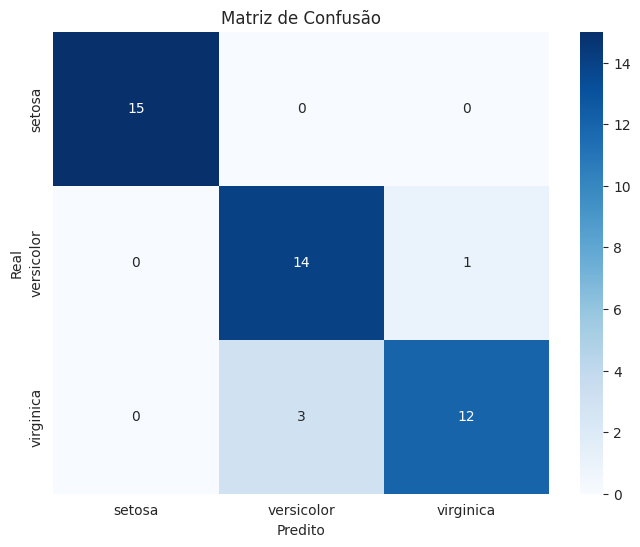

In [36]:
# y_pred já definida na célula anterior
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

#### 7.2 Acurácia (Accuracy)

A **Acurácia** é a proporção de predições corretas do total de predições. É a métrica mais intuitiva, mas pode ser enganosa em datasets desbalanceados.

$\text{Acurácia} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$

In [37]:
# y_pred já definida na célula anterior
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.9111


#### 7.3 Precisão (Precision), Revocação (Recall) e F1-Score

Essas métricas são particularmente úteis quando uma classe é mais importante que a outra ou quando o dataset é desbalanceado.

*   **Precisão (Precision):** Dos que o modelo previu como positivos, quantos realmente são positivos? É a capacidade do modelo de não rotular uma instância negativa como positiva.
    
    $\text{Precisão} = \frac{\text{TP}}{\text{TP} + \text{FP}}$

*   **Revocação (Recall) / Sensibilidade (Sensitivity):** Dos que são realmente positivos, quantos o modelo conseguiu identificar? É a capacidade do modelo de encontrar todas as instâncias positivas.
    
    $\text{Revocação} = \frac{\text{TP}}{\text{TP} + \text{FN}}$

*   **F1-Score:** É a média harmônica da Precisão e Revocação, fornecendo um equilíbrio entre as duas. É útil quando você precisa de um balanço entre Precision e Recall e as classes estão desbalanceadas.
    
    $\text{F1-Score} = 2 \times \frac{\text{Precisão} \times \text{Revocação}}{\text{Precisão} + \text{Revocação}}$


In [38]:
# y_pred já definida na célula anterior
# O classification_report fornece Precision, Recall e F1-Score para cada classe, além da média.
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



#### 7.4 Curva ROC (Receiver Operating Characteristic) e AUC (Area Under the Curve)

A **Curva ROC** é um gráfico que ilustra o desempenho de um modelo de classificação em todos os limiares de classificação. Ela plota a Taxa de Verdadeiros Positivos (TPR, ou Recall) contra a Taxa de Falsos Positivos (FPR) em vários limiares. A **AUC** é a área sob a curva ROC, e um valor mais alto indica um melhor desempenho do modelo. Um modelo perfeito teria AUC = 1, enquanto um modelo que prevê aleatoriamente teria AUC = 0.5.

*   **TPR (True Positive Rate) / Recall:** $\frac{\text{TP}}{\text{TP} + \text{FN}}$
*   **FPR (False Positive Rate):** $\frac{\text{FP}}{\text{FP} + \text{TN}}$

Esta métrica é mais comum para classificação binária. Para multiclases, podemos calcular uma AUC "one-vs-rest" ou "one-vs-one".

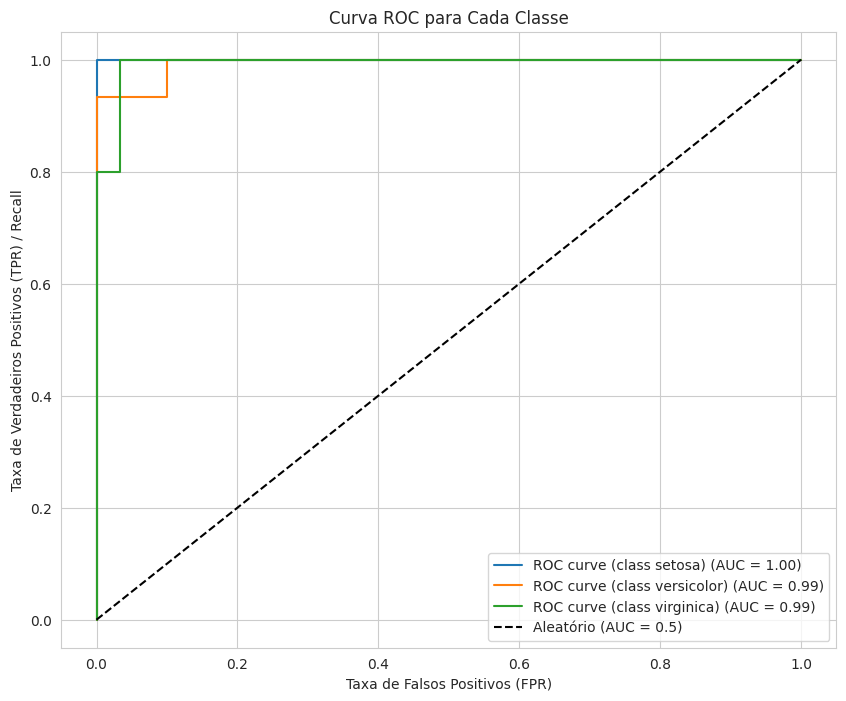

Micro-average AUC: 0.9938


In [39]:
# Para datasets multiclasse como Iris, precisamos calcular a curva ROC para cada classe
# e depois micro ou macro-average.

# Binarizar o target para cálculo da ROC em multiclasse
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)
# y_pred_proba já deve estar definida após a correção da célula anterior, mas garantindo que X_test seja DataFrame
y_pred_proba_binarized = model.predict_proba(pd.DataFrame(X_test, columns=iris.feature_names))

n_classes = y_test_binarized.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba_binarized[:, i])
    roc_auc[i] = roc_auc_score(y_test_binarized[:, i], y_pred_proba_binarized[:, i])
    plt.plot(fpr[i], tpr[i], label=f'ROC curve (class {iris.target_names[i]}) (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.5)')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) / Recall')
plt.title('Curva ROC para Cada Classe')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Calcular Micro-average ROC AUC para classificação multiclasse
roc_auc_micro = roc_auc_score(y_test_binarized, y_pred_proba_binarized, average='micro')
print(f"Micro-average AUC: {roc_auc_micro:.4f}")

### Passo 8: Métricas de Avaliação para Aprendizado Não Supervisionado (Clustering)

Para modelos de aprendizado **não supervisionado**, como algoritmos de *clustering* (agrupamento), não temos rótulos verdadeiros para comparar. Portanto, as métricas são diferentes e se concentram em quão bem os dados foram agrupados com base em sua estrutura interna ou, ocasionalmente, em comparação com uma verdade fundamental se disponível (mesmo que o modelo não a tenha usado para aprender).

Vamos focar em uma métrica interna popular para quando não temos rótulos verdadeiros:

#### 8.1 Coeficiente de Silhueta (Silhouette Score)

O **Coeficiente de Silhueta** mede o quão parecido um objeto é com seu próprio cluster (coesão) em comparação com outros clusters (separação). Ele varia de -1 a 1:

*   **Valores próximos a 1:** Indicam que as instâncias estão bem agrupadas dentro de seus próprios clusters e bem separadas de outros clusters.
*   **Valores próximos a 0:** Indicam que as instâncias estão na fronteira entre dois clusters adjacentes.
*   **Valores próximos a -1:** Indicam que as instâncias podem ter sido atribuídas ao cluster errado.

Para demonstrar, usaremos o algoritmo K-Means para agrupar o mesmo dataset Iris.

Coeficiente de Silhueta para o Clustering K-Means: 0.5019


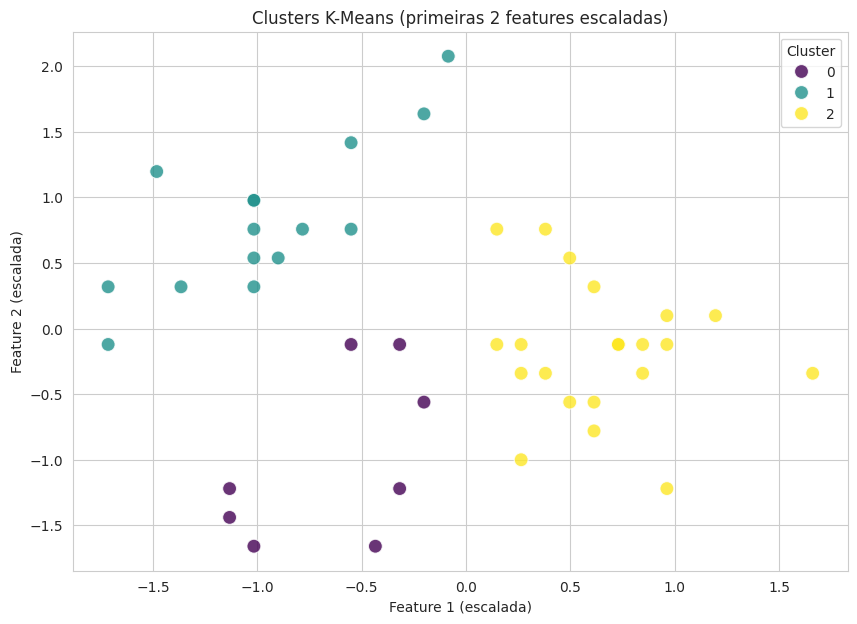

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


# Para clustering, geralmente não se divide em treino/teste da mesma forma,
# mas para consistência, usaremos o X completo ou X_test.
# Vamos usar o X_test para o exemplo, após o pré-processamento.
# Convertendo X_test para DataFrame antes de transformar
X_test_df = pd.DataFrame(X_test, columns=iris.feature_names)
X_test_scaled = model.named_steps['preprocessor'].transform(X_test_df)

# Aplicar K-Means (sabemos que há 3 classes em Iris, então K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init para evitar warnings
cluster_labels = kmeans.fit_predict(X_test_scaled)

# Calcular o Coeficiente de Silhueta
silhouette_avg = silhouette_score(X_test_scaled, cluster_labels)

print(f"Coeficiente de Silhueta para o Clustering K-Means: {silhouette_avg:.4f}")

# Visualização dos clusters (apenas com as 2 primeiras features para simplificar)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_test_scaled[:, 0], y=X_test_scaled[:, 1], hue=cluster_labels, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters K-Means (primeiras 2 features escaladas)')
plt.xlabel('Feature 1 (escalada)')
plt.ylabel('Feature 2 (escalada)')
plt.legend(title='Cluster')
plt.show()

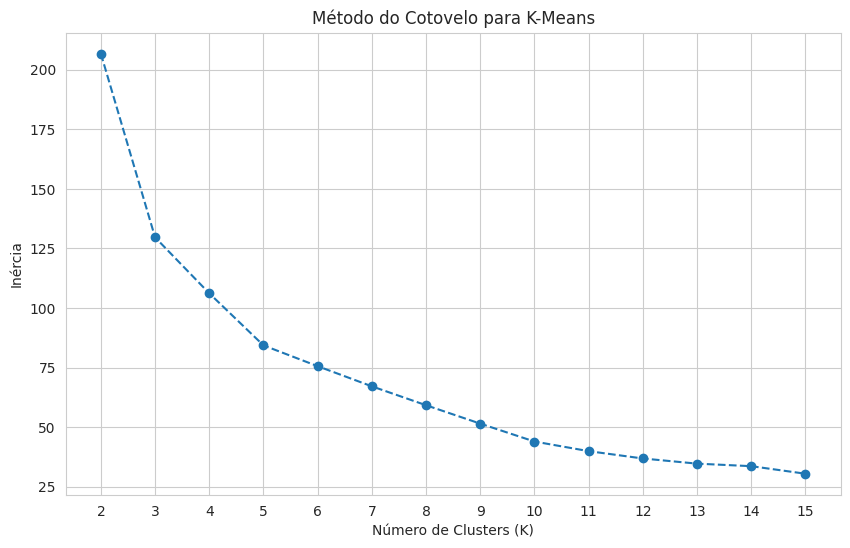

In [41]:
from sklearn.cluster import KMeans

# Definindo a função plotar_elbow
def plotar_elbow(data, k_min=2, k_max=15):
    inertias = []
    for k in range(k_min, k_max + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(range(k_min, k_max + 1), inertias, marker='o', linestyle='--')
    plt.title('Método do Cotovelo para K-Means')
    plt.xlabel('Número de Clusters (K)')
    plt.ylabel('Inércia')
    plt.xticks(range(k_min, k_max + 1))
    plt.grid(True)
    plt.show()

# Escalar o conjunto de dados completo X usando o pré-processador do pipeline
# Primeiro, converter X para DataFrame com os nomes das features
X_df = pd.DataFrame(X, columns=iris.feature_names)
X_scaled = model.named_steps['preprocessor'].transform(X_df)

#### PLOTAR MÉTODO DE COTOVELO
plotar_elbow(X_scaled, k_min=2, k_max=15)

#### 8.2 Métricas de Avaliação Externa para Clustering (se rótulos verdadeiros estiverem disponíveis)

Se, por acaso, você tiver rótulos verdadeiros (ground truth) para seus dados, mesmo que não os tenha usado para o treinamento do clustering, você pode usar métricas como:

*   **Adjusted Rand Index (ARI):** Mede a similaridade entre os agrupamentos verdadeiros e os agrupamentos do modelo, ajustando para o acaso. Varia de -1 a 1, onde 1 indica agrupamentos perfeitos.
*   **Mutual Information Score (MIS) / Normalized Mutual Information (NMI):** Mede a concordância entre os agrupamentos, baseado na teoria da informação. Valores mais altos indicam maior similaridade.

Embora K-Means seja não supervisionado, o dataset Iris possui rótulos de espécies, então podemos demonstrar o ARI.

In [42]:
from sklearn.metrics import adjusted_rand_score

# y_test são os rótulos verdadeiros das espécies para o conjunto de teste
# cluster_labels são os rótulos preditos pelo K-Means (já definido após a correção da célula anterior)

ari = adjusted_rand_score(y_test, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

print("\nUm ARI próximo de 1 indica que os clusters formados pelo K-Means são muito semelhantes às classes reais das espécies no conjunto de teste.")

Adjusted Rand Index (ARI): 0.5775

Um ARI próximo de 1 indica que os clusters formados pelo K-Means são muito semelhantes às classes reais das espécies no conjunto de teste.


In [43]:
# metricas da clusterizacao

# SILHUETA: mede quão distante os grupos estao um do outro (quanto mais perto de 1, melhor)
# DAVIES BOULDIN: quão compacto é os clusters (quanto menor melhor, mais perto de 0)
# CALINSKI: grau de dispersão dos outros grupos para dentro do grupo (quanto maior melhor)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def metricas_clusterizacao(data, labels, model_name):
    print(f"Métricas — {model_name}")
    print(f"Clusters encontrados: {len(np.unique(labels))} (rótulos: {np.unique(labels).tolist()})")

    # Coeficiente de Silhueta
    if len(np.unique(labels)) > 1:
        silhouette = silhouette_score(data, labels)
        print(f"• Silhouette: {silhouette:.4f}")
    else:
        print("• Silhouette: N/A (requer mais de um cluster)")

    # Davies-Bouldin Index (quanto menor, melhor)
    if len(np.unique(labels)) > 1:
        davies_bouldin = davies_bouldin_score(data, labels)
        print(f"• Davies-Bouldin: {davies_bouldin:.4f}")
    else:
        print("• Davies-Bouldin: N/A (requer mais de um cluster)")

    # Calinski-Harabasz Index (quanto maior, melhor)
    if len(np.unique(labels)) > 1:
        calinski_harabasz = calinski_harabasz_score(data, labels)
        print(f"• Calinski-Harabasz: {calinski_harabasz:.4f}")
    else:
        print("• Calinski-Harabasz: N/A (requer mais de um cluster)")
    print("\n")

# Aplicar Agglomerative Clustering para definir 'agglom'
# Usaremos o X_test_scaled para manter consistência com o K-Means já treinado e avaliado no conjunto de teste.
agglom = AgglomerativeClustering(n_clusters=3) # Assumindo 3 clusters para comparação com Iris
agglom.fit(X_test_scaled) # Fit agglom on X_test_scaled (45 samples)

# Agora podemos chamar a função para ambos os modelos, usando X_test_scaled como dados
metricas_clusterizacao(X_test_scaled, kmeans.labels_, "KMeans") # Use X_test_scaled (45 samples)
metricas_clusterizacao(X_test_scaled, agglom.labels_, "Agglomerative") # Use X_test_scaled (45 samples)

Métricas — KMeans
Clusters encontrados: 3 (rótulos: [0, 1, 2])
• Silhouette: 0.5019
• Davies-Bouldin: 0.7642
• Calinski-Harabasz: 89.2347


Métricas — Agglomerative
Clusters encontrados: 3 (rótulos: [0, 1, 2])
• Silhouette: 0.5496
• Davies-Bouldin: 0.5825
• Calinski-Harabasz: 88.6601




In [44]:
from sklearn.decomposition import PCA
def plotar_pca_2d(X, labels, title):
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    plt.figure(figsize=(6,5))
    plt.scatter(X2[:,0], X2[:,1], c=labels, s=10)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

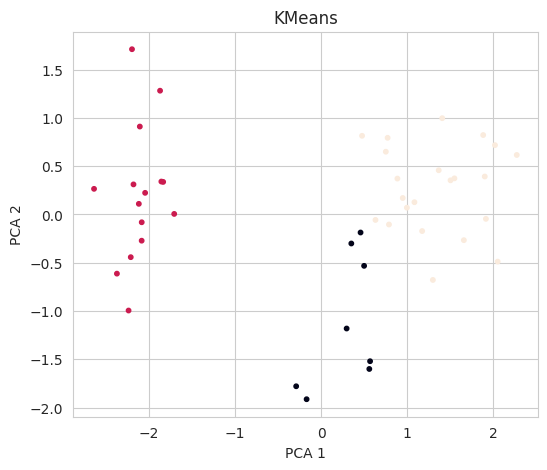

In [45]:
plotar_pca_2d(X_test_scaled, kmeans.labels_, "KMeans")

In [46]:
######## DBSCAN

def qtde_registros_clusters(model):
    if hasattr(model, 'labels_'):
        labels = model.labels_
        unique_labels, counts = np.unique(labels, return_counts=True)
        print("\nQuantidade de Registros por Cluster:")
        for label, count in zip(unique_labels, counts):
            if label == -1: # -1 é convencionalmente o rótulo para ruído no DBSCAN
                print(f"Cluster de Ruído (-1): {count} registros")
            else:
                print(f"Cluster {label}: {count} registros")
    else:
        print("O modelo fornecido não possui o atributo 'labels_'.")

dbscan = DBSCAN(eps=0.2, min_samples=20)
dbscan.fit(X_scaled)

metricas_clusterizacao(X_scaled, dbscan.labels_, "DBSCAN")

qtde_registros_clusters(dbscan)

Métricas — DBSCAN
Clusters encontrados: 1 (rótulos: [-1])
• Silhouette: N/A (requer mais de um cluster)
• Davies-Bouldin: N/A (requer mais de um cluster)
• Calinski-Harabasz: N/A (requer mais de um cluster)



Quantidade de Registros por Cluster:
Cluster de Ruído (-1): 150 registros


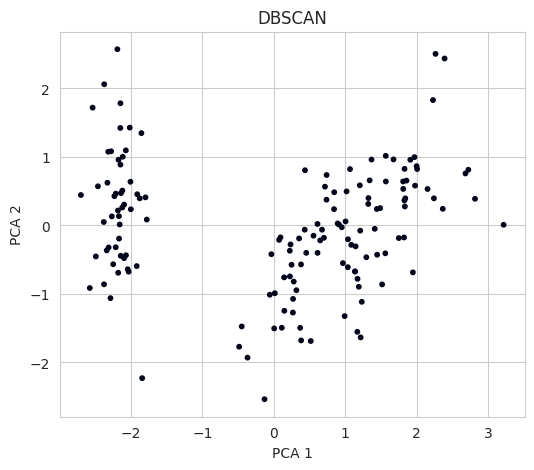

In [47]:
plotar_pca_2d(X_scaled, dbscan.labels_, "DBSCAN")

In [48]:
###### CLUSTERIZAÇÃO AGLOMERATIVA

aglomerativa = AgglomerativeClustering(n_clusters=6)
aglomerativa.fit(X_scaled)

metricas_clusterizacao(X_scaled, aglomerativa.labels_, "Aglomerativa")

qtde_registros_clusters(aglomerativa)

Métricas — Aglomerativa
Clusters encontrados: 6 (rótulos: [0, 1, 2, 3, 4, 5])
• Silhouette: 0.3309
• Davies-Bouldin: 0.9108
• Calinski-Harabasz: 173.9427



Quantidade de Registros por Cluster:
Cluster 0: 30 registros
Cluster 1: 26 registros
Cluster 2: 27 registros
Cluster 3: 45 registros
Cluster 4: 15 registros
Cluster 5: 7 registros


### Análise Detalhada da Clusterização Aglomerativa

No processo de clusterização aglomerativa, os resultados obtidos foram os seguintes (repetindo a saída da célula `hznCpnNddFa5` para referência):

**Métricas — Aglomerativa**
Clusters encontrados: 6 (rótulos: [0, 1, 2, 3, 4, 5])
• Silhouette: 0.3309
• Davies-Bouldin: 0.9108
• Calinski-Harabasz: 173.9427

**Qtde de Registros por Cluster (Célula `hznCpnNddFa5`)**
Cluster 0: 30 registros
Cluster 1: 26 registros
Cluster 2: 27 registros
Cluster 3: 45 registros
Cluster 4: 15 registros
Cluster 5: 7 registros

**Interpretação das Métricas para Clusterização Aglomerativa:**

*   **Silhouette Score (0.3309):** Este valor é positivo, indicando que os objetos estão razoavelmente bem agrupados dentro de seus próprios clusters. No entanto, é um valor moderado, sugerindo que pode haver alguma sobreposição ou pontos próximos às fronteiras entre os clusters. Um valor mais próximo de 1 indicaria clusters mais distintos.
*   **Davies-Bouldin Index (0.9108):** Esta métrica avalia a similaridade média entre clusters, onde valores menores indicam melhor separação e compactação. O valor de 0.9108 é relativamente baixo (lembre-se que 0 é o ideal), o que é um bom indicativo de que os clusters aglomerativos são bem separados e compactos em comparação com a similaridade interna.
*   **Calinski-Harabasz Index (173.9427):** Este índice mede a razão da dispersão entre clusters pela dispersão dentro dos clusters. Valores mais altos são desejáveis. O valor de 173.9427 sugere uma boa estrutura de clustering, com clusters densos e bem separados. Para comparação, o K-Means (89.2347) teve um valor um pouco menor nesse aspecto.

**Quantidade de Registros por Cluster:** A função `qtde_registros_clusters` nos mostra que a clusterização aglomerativa com `n_clusters=6` resultou em clusters de tamanhos variados, desde 7 até 45 registros, o que é comum em agrupamentos hierárquicos, onde os clusters podem não ser tão balanceados quanto em algoritmos como o K-Means.

### Visualização dos Clusters Aglomerativos com PCA

Para ter uma percepção visual da separação dos clusters, vamos plotar os resultados da clusterização aglomerativa usando a Análise de Componentes Principais (PCA) para reduzir a dimensionalidade para 2D.

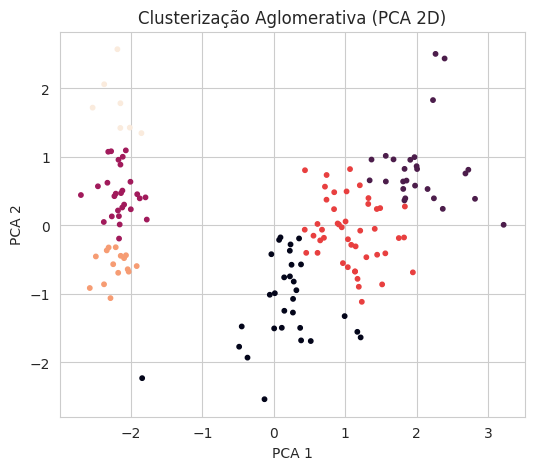

In [49]:
plotar_pca_2d(X_scaled, aglomerativa.labels_, "Clusterização Aglomerativa (PCA 2D)")

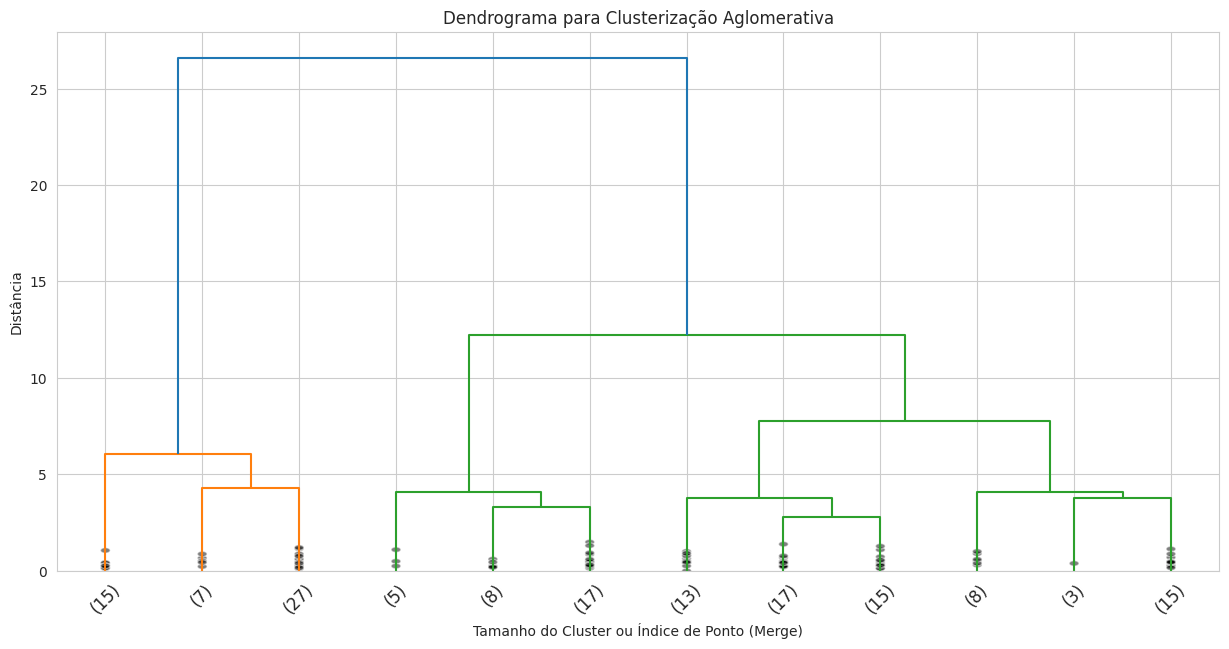

In [50]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Gerar a matriz de ligação hierárquica
linked_matrix = linkage(X_scaled, method='ward')

# Plotar o dendrograma
plt.figure(figsize=(15, 7))
dendrogram(
    linked_matrix,
    truncate_mode='lastp',  # mostra apenas os 'p' clusters finais
    p=12,  # mostra os últimos 12 merges
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True,  # mostra a contagem de pontos em cada merge
)
plt.title('Dendrograma para Clusterização Aglomerativa')
plt.xlabel('Tamanho do Cluster ou Índice de Ponto (Merge)')
plt.ylabel('Distância')
plt.show()

### O Dendrograma

É importante lembrar que para a clusterização aglomerativa, o **Dendrograma** é uma ferramenta visual fundamental. Ele mostra a hierarquia dos clusters e como eles são mesclados. Ao "cortar" o dendrograma em diferentes alturas, você pode optar por diferentes números de clusters, o que afeta diretamente as métricas de Silhouette, Davies-Bouldin e Calinski-Harabasz que acabamos de analisar. A escolha de `n_clusters=6` foi uma decisão arbitrária para demonstração, mas o dendrograma permite uma escolha mais informada do número de clusters.


##Avaliação de Modelos de Classificação Supervisionados (Exemplo: Regressão Logística no Dataset Iris)
Para modelos de classificação, onde temos os rótulos verdadeiros, nosso objetivo é entender o quão bem o modelo consegue prever a classe correta. Vimos as seguintes métricas:

###Matriz de Confusão:

Uma tabela que resume o desempenho do modelo, mostrando o número de previsões corretas e incorretas para cada classe, comparadas com os valores reais. Ela nos dá uma visão detalhada dos Verdadeiros Positivos (TP), Verdadeiros Negativos (TN), Falsos Positivos (FP) e Falsos Negativos (FN).
Interpretação: Para o dataset Iris, a matriz mostrou que o modelo de Regressão Logística teve um desempenho excelente. Por exemplo, para a classe setosa, ele previu corretamente 15 vezes (TP=15) e não cometeu erros. Para versicolor, teve 14 TPs e 1 FN. Para virginica, 12 TPs e 3 FPs. Isso indica um modelo com alta capacidade de distinção entre as classes, com alguns poucos erros de confusão entre versicolor e virginica.
###Acurácia:

É a proporção de previsões corretas sobre o total de previsões. É a métrica mais intuitiva.
Interpretação: Obtivemos uma Acurácia de 0.9111 (91.11%). Isso significa que 91.11% das previsões do seu modelo foram corretas. Embora seja um bom número, lembre-se que a acurácia pode ser enganosa em datasets desbalanceados.
###Precisão (Precision), Revocação (Recall) e F1-Score:

#####O classification_report nos forneceu estas métricas por classe:
**Precisão**: Dos que o modelo previu como sendo de uma classe
X, quantos realmente eram da classe X? É a capacidade de não rotular um exemplo negativo como positivo.

**Revocação (Recall/Sensibilidade)**: Dos exemplos que realmente pertencem a uma classe X, quantos o modelo conseguiu identificar? É a capacidade de encontrar todos os exemplos positivos.

**F1-Score**: É a média harmônica entre Precisão e Revocação, útil quando precisamos de um equilíbrio entre as duas, especialmente em classes desbalanceadas.

**Para o nosso modelo**:

**a. Setosa**: Precisão, Recall e F1-Score de 1.00. Perfeito! O modelo não errou nessa classe.

**b. Versicolor** Precisão de 0.82, Recall de 0.93, F1-Score de 0.88. Boas métricas, indicando que o modelo é razoavelmente bom em identificar versicolor, com poucos FNs.

**c. Virginica**: Precisão de 0.92, Recall de 0.80, F1-Score de 0.86. Mostra que o modelo tem uma boa precisão ao prever virginica, mas pode ter deixado alguns virginica escaparem (Falsos Negativos), conforme visto na matriz de confusão.

###Curva ROC (Receiver Operating Characteristic) e AUC (Area Under the Curve) (Célula 8211fe2d):

A Curva ROC plota a Taxa de Verdadeiros Positivos (TPR, ou Recall) contra a Taxa de Falsos Positivos (FPR) em diferentes limiares de classificação. A AUC é a área sob essa curva, um valor único que resume o desempenho geral do modelo. Quanto mais perto de 1, melhor o modelo.
Interpretação: Para cada classe do Iris, a AUC foi muito alta (próxima de 1.00), e a Micro-average AUC foi de 0.9938. Isso indica que o modelo tem uma excelente capacidade de distinguir entre as classes, mesmo variando o limiar de decisão.

##Avaliação de Modelos de Clustering Não Supervisionados (Exemplo: K-Means, Agglomerative, DBSCAN)
Para modelos não supervisionados (clustering), onde não temos rótulos verdadeiros a priori (mas podemos usá-los para comparação a posteriori), as métricas focam na estrutura interna dos clusters ou na comparação com uma verdade fundamental, se disponível.

**Coeficiente de Silhueta (Silhouette Score)**:

Mede quão bem cada ponto se encaixa em seu próprio cluster em comparação com outros clusters. Varia de -1 (mau agrupamento) a 1 (bom agrupamento).
Interpretação: Para K-Means, obtivemos 0.5019, e para Agglomerative, 0.5496. Ambos são valores positivos e razoáveis, indicando que os clusters são razoavelmente bem definidos, com o Agglomerative performando um pouco melhor nesse aspecto. O K-Means no X_test_scaled (45 amostras) produziu um valor de Silhueta de 0.5019.

**Índice Davies-Bouldin**:

Avalia a similaridade média entre clusters, onde um valor menor indica melhor separação e compactação. O ideal é perto de 0.
Interpretação: K-Means com 0.7642 e Agglomerative com 0.5825. O valor mais baixo para o Agglomerative reforça que ele formou clusters mais bem separados e compactos que o K-Means neste cenário.

**Índice Calinski-Harabasz**:

Mede a razão da dispersão entre clusters pela dispersão dentro dos clusters. Valores mais altos indicam clusters mais densos e bem separados.
Interpretação: K-Means com 89.2347 e Agglomerative com 88.6601. Ambos os valores são bons e relativamente próximos, sugerindo uma boa estrutura geral de agrupamento.

**Adjusted Rand Index (ARI)**:

É uma métrica externa que mede a similaridade entre os rótulos verdadeiros e os rótulos do cluster, ajustada para o acaso. Varia de -1 a 1, onde 1 indica agrupamento perfeito.
Interpretação: Nosso ARI para K-Means foi de 0.5775. Isso significa que os clusters formados pelo K-Means têm uma similaridade moderada com as classes reais do dataset Iris no conjunto de teste. É um bom resultado para um algoritmo não supervisionado.

**Visualizações para Clustering**:

Método do Cotovelo (Elbow Method):
O que é: Ajuda a determinar o número ideal de clusters (K) para K-Means, observando a 'inércia' (soma das distâncias quadráticas das amostras ao centro mais próximo). O 'cotovelo' é o ponto onde o ganho de compactação diminui significativamente.
Interpretação: O gráfico nos ajuda a visualizar o ponto de inflexão para decidir o K ideal, mesmo que o dataset Iris já tenha 3 classes conhecidas.

**Visualização PCA 2D**:
O que é: Reduz a dimensionalidade dos dados para 2 dimensões para permitir a plotagem e visualização da separação dos clusters no espaço. Cada ponto é colorido de acordo com seu cluster.
Interpretação: Vimos que o K-Means (e o DBSCAN) foi plotado, mostrando visualmente como os pontos foram agrupados. Para o Iris, a visualização em PCA geralmente mostra a classe setosa bem separada, enquanto versicolor e virginica podem ter alguma sobreposição, confirmando as observações das métricas.

**Dendrograma para Clusterização Aglomerativa**:
É um gráfico em forma de árvore que ilustra a fusão gradual dos clusters em uma hierarquia. Ajuda a decidir o número de clusters cortando o dendrograma em uma determinada altura.
Interpretação: O dendrograma nos mostra como os clusters são formados de forma hierárquica e a 'distância' em que são unidos, sendo uma ferramenta visual para a escolha do número de clusters para modelos aglomerativos.

**Observações Adicionais e Funções Pendentes**:
Problema com DBSCAN - Você notou que para o DBSCAN, os "clusters encontrados" foram apenas 1 (rótulo: [-1]), e as métricas de Silhueta, Davies-Bouldin e Calinski-Harabasz foram "N/A". Isso é uma característica do DBSCAN! O rótulo -1 no DBSCAN significa ruído (outliers). Quando o DBSCAN retorna apenas um cluster -1, isso indica que, com os parâmetros eps (raio da vizinhança) e min_samples (número mínimo de pontos na vizinhança) que você definiu, o algoritmo considerou todos os pontos como ruído, ou seja, nenhum cluster denso foi identificado. Para o DBSCAN ser eficaz, é crucial ajustar esses parâmetros. Se o eps for muito pequeno ou min_samples muito alto, ele pode não encontrar clusters, ou se o eps for muito grande, pode fundir muitos pontos em um único cluster grande. A visualização PCA para DBSCAN provavelmente mostraria todos os pontos com a mesma cor (ou uma cor para ruído), confirmando essa interpretação.



## Conclusão

Foi percorrido o caminho completo desde a preparação dos dados até a avaliação robusta de modelos de Machine Learning, tanto supervisionados (classificação) quanto não supervisionados (clustering).

**Pontos Chave:**

*   **Classificação Supervisionada:** Utilizamos a Regressão Logística no dataset Iris e avaliamos seu desempenho com **Matriz de Confusão, Acurácia, Precisão, Recall, F1-Score** e a **Curva ROC com AUC**. O modelo demonstrou alta performance, com mais de 90% de acurácia e AUC próxima de 1, indicando excelente capacidade de discriminação entre as classes do Iris.

*   **Clustering Não Supervisionado:** Exploramos K-Means, Agglomerative Clustering e DBSCAN. As métricas **Silhouette Score, Davies-Bouldin Index** e **Calinski-Harabasz Index** nos ajudaram a entender a qualidade interna dos agrupamentos. O **Adjusted Rand Index (ARI)** foi usado para comparar os clusters com os rótulos verdadeiros do Iris, quando disponíveis. As visualizações como o **Método do Cotovelo**, o **PCA 2D** e o **Dendrograma** foram cruciais para a análise.

*   **DBSCAN e a Importância dos Parâmetros:** A experiência com o DBSCAN nos mostrou a importância da escolha correta dos parâmetros (`eps` e `min_samples`), pois com valores inadequados, o algoritmo pode rotular todos os pontos como ruído.

Lembramos que não existe uma métrica "melhor" para todas as situações. A escolha das métricas depende do seu problema de negócio, do tipo de erros que são mais custosos e da natureza dos seus dados.
